In [1]:
try: 
    import kagglehub #pip install kagglehub
    kagglehub.login()
    path = kagglehub.competition_download('aca-butterflies')
    print("Path to dataset files:", path)
    
except ImportError as e:
    from pathlib import Path
    path = Path().cwd()  / "aca-butterflies"

In [2]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.utils.data as data
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from multiprocessing import Process, freeze_support
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
from torch.utils.data import Subset
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim # optimizadors
import numpy as np
import optuna
import time
import matplotlib.pyplot as plt
import copy

c:\Users\Xaneca\miniconda3\envs\ACA_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [3]:
BATCH_SIZE = 32
IMAGE_SIZE = 64

In [4]:
class ButterflyDataset(data.Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.img_labels = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

        self.classes = sorted(self.img_labels['label'].unique())
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_name = self.img_labels.iloc[idx]['filename']
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        label_name = self.img_labels.iloc[idx]['label']
        label_idx = self.class_to_idx[label_name]
        label = torch.tensor(label_idx, dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label

## First, we read the dataset, preprocess the images and encapsulate them into dataloader form.

In [5]:
# load the data
img_dir = os.path.join(path, 'train')
df = pd.read_csv(os.path.join(path, 'train.csv'))

# preprocessing
data_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

# encapsulate data into dataloader form
dataset = ButterflyDataset(df=df, img_dir=img_dir, transform=data_transform)
dataloader = data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

### Train/Test 70/30 : Stratified

In [6]:
targets = dataset.img_labels['label'].values 

# Stratified: 70 / 30
train_indices, val_indices = train_test_split(
    range(len(dataset)),
    test_size=0.3,
    stratify=targets,
    random_state=42
)

# DATA AUGMENTATION FOR TRAINING SET
train_transform = v2.Compose([      # ⚠️ ver se aplica de maneira igual a todos as classes
    v2.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    v2.RandomHorizontalFlip(),
    v2.RandomRotation(15),
    v2.ToTensor(),
    # v2.Normalize((0.5,), (0.5,))
])

# Subsets
train_dataset = Subset(dataset, train_indices)
train_dataset.dataset = copy.copy(dataset)
train_dataset.dataset.transform = train_transform  # Apply augmentation only to training set
val_dataset = Subset(dataset, val_indices)

# DataLoaders
train_loader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Imagens para treino: {len(train_dataset)}")
print(f"Imagens para validação: {len(val_dataset)}")

Imagens para treino: 3639
Imagens para validação: 1560


c:\Users\Xaneca\miniconda3\envs\ACA_venv\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:41: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.
  warnings.warn(


In [7]:
# VERIFY SAMPLES AND CLASSES
print(f"Number of samples: {len(dataset)}")
print(f"Number of classes: {len(dataset.classes)}")

Number of samples: 5199
Number of classes: 75


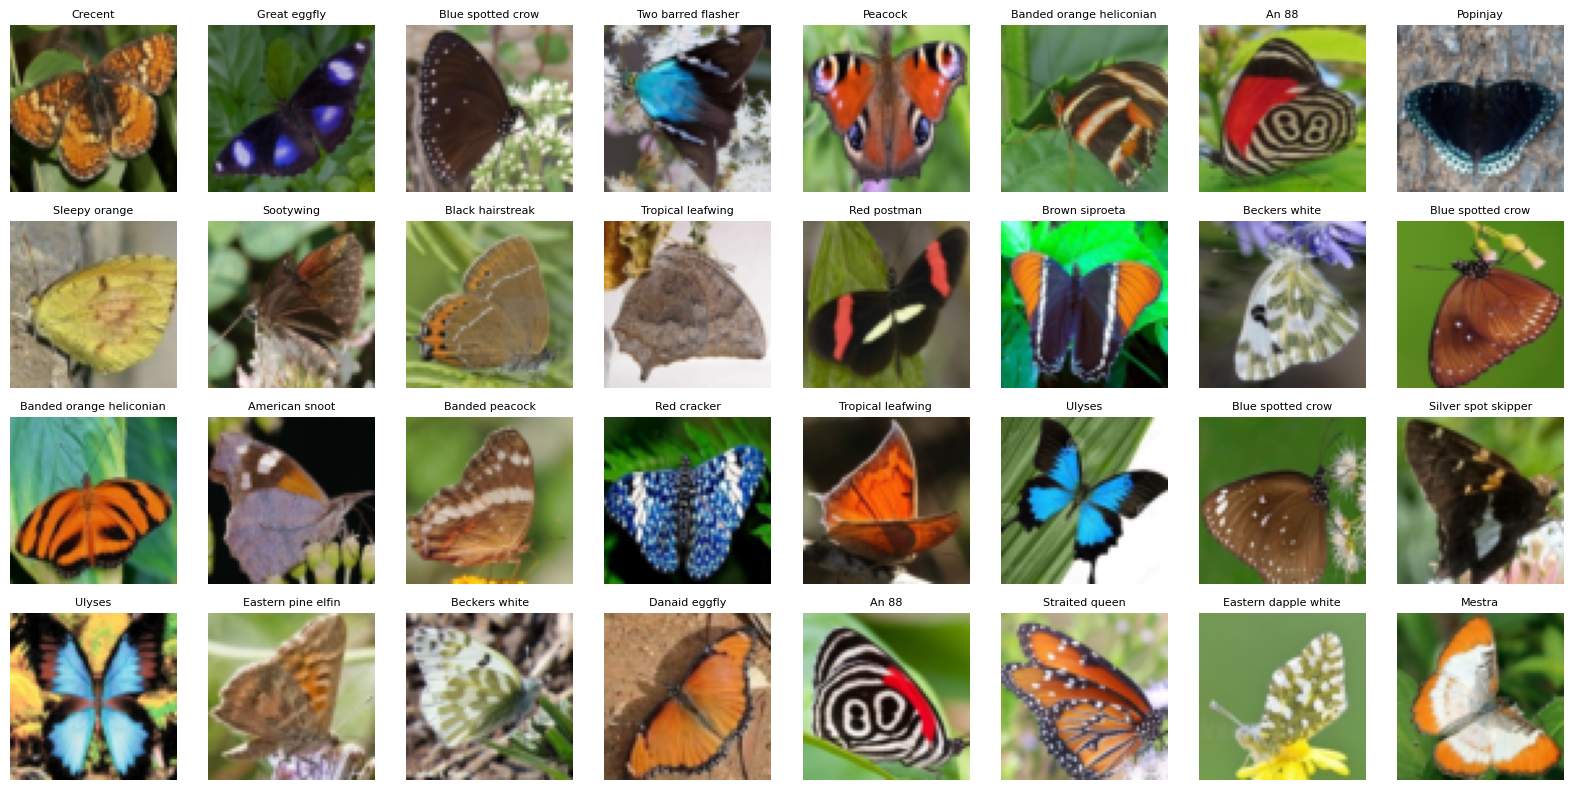

In [8]:
# Get a batch of images from the dataloader
images, labels = next(iter(dataloader))

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for i in range(len(images)):
    img = images[i].permute(1, 2, 0).numpy()
    label_idx = labels[i].item()
    label_name = dataset.classes[label_idx]

    axes[i].imshow(img)
    axes[i].set_title(label_name.capitalize(), fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# First Simple Aproach

In [9]:
class Net(nn.Module):
    '''Models a simple Convolutional Neural Network'''

    def __init__(self):
        super(Net, self).__init__()

        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(6, 16, 5)

        self.fc1 = nn.Linear(16 * 13 * 13, 120)

        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 75)

    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))  
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(-1, 16 * 13 * 13)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x


# Second Robust Approach

In [10]:
class RobustNet(nn.Module):

    def __init__(self, num_classes=75):
        super(RobustNet, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)  
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) 
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) 
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1) 

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)

        # Fully connected layers
        self.fc1 = nn.Linear(256 * 4 * 4, 512)  # ajustado após pooling
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)

    def forward(self, x):
        # Convolutional blocks
        x = F.relu(self.conv1(x))
        x = self.pool(x)  # 64 -> 32

        x = F.relu(self.conv2(x))
        x = self.pool(x)  # 32 -> 16

        x = F.relu(self.conv3(x))
        x = self.pool(x)  # 16 -> 8

        x = F.relu(self.conv4(x))
        x = self.pool(x)  # 8 -> 4

        # Flatten
        x = x.view(-1, 256 * 4 * 4)

        # Fully connected
        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        x = F.relu(self.fc2(x))
        x = self.dropout(x)

        x = self.fc3(x)  # sem ReLU final, pois CrossEntropyLoss já faz softmax

        return x


# Final CNN

In [11]:
class SuperNet(nn.Module):
    '''High-performance CNN for 64x64 images, 75 classes'''

    def __init__(self, num_classes=75):
        super(SuperNet, self).__init__()

        # --- Convolutional Block 1 ---
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2)  # 64 -> 32
        )

        # --- Convolutional Block 2 ---
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2)  # 32 -> 16
        )

        # --- Convolutional Block 3 ---
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2)  # 16 -> 8
        )

        # --- Convolutional Block 4 ---
        self.block4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1,1))  # global average pooling
        )

        # --- Fully Connected Layer ---
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

        # Inicialização He
        self._initialize_weights()

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.fc(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, a=0, nonlinearity='relu')
                nn.init.zeros_(m.bias)

### CNN with Optuna

In [16]:
# DEVICE (GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# MODEL
class SuperNet(nn.Module):
    def __init__(self, config, num_classes=75, folder="Results/CNN/", filename=None, plot=True):
        super(SuperNet, self).__init__()

        k = config["kernel_size"]
        p = k // 2
        s = config["stride"]
        pool = config["pool"]
        dropout = config["dropout"]
        self.filename = filename    # Name of CSV and PTH file
        self.folder = folder
        self.plot = plot

        c1, c2, c3, c4 = config["channels"]

        def get_pool():
            return nn.MaxPool2d(2,2) if pool == "max" else nn.AvgPool2d(2,2)

        self.block1 = nn.Sequential(
            nn.Conv2d(3, c1, k, stride=s, padding=p),
            nn.BatchNorm2d(c1),
            nn.ReLU(),
            nn.Conv2d(c1, c1, k, padding=p),
            nn.BatchNorm2d(c1),
            nn.ReLU(),
            get_pool()
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(c1, c2, k, stride=s, padding=p),
            nn.BatchNorm2d(c2),
            nn.ReLU(),
            nn.Conv2d(c2, c2, k, padding=p),
            nn.BatchNorm2d(c2),
            nn.ReLU(),
            get_pool()
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(c2, c3, k, padding=p),
            nn.BatchNorm2d(c3),
            nn.ReLU(),
            nn.Conv2d(c3, c3, k, padding=p),
            nn.BatchNorm2d(c3),
            nn.ReLU(),
            get_pool()
        )

        self.block4 = nn.Sequential(
            nn.Conv2d(c3, c4, k, padding=p),
            nn.BatchNorm2d(c4),
            nn.ReLU(),
            nn.Conv2d(c4, c4, k, padding=p),
            nn.BatchNorm2d(c4),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(c4, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.fc(x)
        return x

# TRAIN + EVAL
def evaluate(model, dataloader, criterion):
    model.eval()
    correct = 0
    total = 0
    loss_total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss_total += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    loss_avg = loss_total / len(dataloader)
    return acc, loss_avg


# FIT FUNCTION (EARLY STOP + PRUNING)
def fit(model, train_loader, val_loader, optimizer, criterion, trial,
        epochs=20, patience=5, folder="Results/CNN/", filename=None, plot=True):

    train_acc_graph, val_acc_graph = [], []
    train_loss_graph, val_loss_graph = [], []
    time_values = []

    best_val_loss = float("inf")
    best_val_acc = 0
    p = 0

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_acc, _ = evaluate(model, train_loader, criterion)
        val_acc, val_loss = evaluate(model, val_loader, criterion)
        train_loss = total_loss / len(train_loader)

        # PRUNING (Optuna)
        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        # EARLY STOPPING
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            p = 0
        else:
            p += 1

        if p >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

        # STORE
        train_acc_graph.append(train_acc * 100)
        val_acc_graph.append(val_acc * 100)
        train_loss_graph.append(train_loss)
        val_loss_graph.append(val_loss)
        time_values.append(time.time() - start_time)

        print(f"[{epoch+1}] Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")

    # PLOTS
    plt.figure()
    plt.plot(train_acc_graph, label="Train Acc")
    plt.plot(val_acc_graph, label="Val Acc")
    plt.legend()
    plt.title("Accuracy")
    plt.savefig(folder + f"acc_{filename}.png")
    plt.close()

    plt.figure()
    plt.plot(train_loss_graph, label="Train Loss")
    plt.plot(val_loss_graph, label="Val Loss")
    plt.legend()
    plt.title("Loss")
    plt.savefig(folder + f"loss_{filename}.png")
    plt.close()

    df = pd.DataFrame({"train_acc": train_acc_graph, "val_acc": val_acc_graph, "train_loss": train_loss_graph, "val_loss": val_loss_graph, "time": time_values})
    if filename is not None:
        df.to_csv(folder + filename + ".csv", index=True, index_label="epoch")

    
    return best_val_acc, epoch + 1


Using device: cuda


In [21]:
MAX_EPOCHS = 70
PATIENCE = 10
NUM_TRIALS = 30

In [ ]:
# OPTUNA OBJECTIVE
def objective(trial):

    losses = {  # guarda as classes, nao as instancias
        'CrossEntropy': nn.CrossEntropyLoss,
        # 'MSE': nn.MSELoss,
        'MultiMargin': nn.MultiMarginLoss
    }

    opt = { # guarda as classes, nao as instancias
        'ADAM': torch.optim.Adam,
        'RMS': torch.optim.RMSprop,
        # 'SGD': torch.optim.SGD
    }

    config = {
        "kernel_size": trial.suggest_categorical("kernel_size", [3,5]),
        "stride": trial.suggest_categorical("stride", [1,2]),
        "pool": trial.suggest_categorical("pool", ["max","avg"]),
        "dropout": trial.suggest_categorical("dropout", [0.2, 0.3, 0.4, 0.5, 0.6]),

        "channels": [
            trial.suggest_categorical("c1", [32,64]),
            trial.suggest_categorical("c2", [64,128]),
            trial.suggest_categorical("c3", [128,256]),
            trial.suggest_categorical("c4", [256,512])
        ],

        "lr": trial.suggest_categorical('learning_rate', [1e-4, 1e-3, 1e-2, 1e-1]),
        # "patience": trial.suggest_int("patience", 2, 10)
    }

    model = SuperNet(config, filename=f"trial_{trial.number}", plot=False).to(device)

    loss_name = trial.suggest_categorical('loss_fn', list(losses.keys()))
    criterion = losses[loss_name]()

    opt_name = trial.suggest_categorical('optimizer', list(opt.keys()))
    optimizer = opt[opt_name](model.parameters(), lr=config["lr"])

    acc, epochs_used = fit(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        trial,
        epochs=MAX_EPOCHS,
        patience=PATIENCE,
        folder="Results/CNN/optuna/",
        filename=f"trial_{trial.number}",
        plot=False
    )

    trial.set_user_attr("epochs_used", epochs_used)

    return acc

folder_path = "Results/CNN/optuna/"

# RUN STUDY
study = optuna.create_study(
    study_name="CNN_study_acc",
    direction="maximize",
    sampler=optuna.samplers.TPESampler(),   # ou GaussianProcessSampler (GP)
    storage=f"sqlite:///{folder_path}optuna_cnn_study_acc.db",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
    load_if_exists=True
)

study.optimize(objective, n_trials=NUM_TRIALS)


print("\n" + "="*30)
print("BEST TRIAL RESULTS")
print("="*30)

print(f"Best Trial: #{study.best_trial.number}")
print(f"Best Accuracy Achieved: {study.best_trial.value:.4f}")

print("\nBest Hyperparameters Found:")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")

print("="*30)

# use: optuna-dashboard sqlite:///optuna_cnn_study_acc.db